## Mount & Path

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
 
# path_file  = '/content/drive/MyDrive/tesisugm/' #google colab
path_file = ''  # local

KOMPOSISI  = "lightgbm_balanced_weighted"

## Load Features Module

In [2]:
import importlib.util, sys
 
# MODULE_PATH = "/content/drive/MyDrive/tesisugm/no-leakage/features.py"
MODULE_PATH = "features.py"

spec    = importlib.util.spec_from_file_location("features", MODULE_PATH)
features = importlib.util.module_from_spec(spec)
sys.modules["features"] = features
spec.loader.exec_module(features)
print("Features file   :", features.__file__)
print("Features version:", features.FEATURES_VERSION)

Features file   : features.py
Features version: Shami Extractor


## Imports

In [3]:
import os, gc, warnings, hashlib, itertools, time
import numpy as np
import pandas as pd
import lightgbm as lgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.sparse import hstack, csr_matrix, issparse
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import LabelEncoder, normalize
from sklearn.metrics          import (accuracy_score, f1_score,
                                      classification_report, confusion_matrix,
                                      silhouette_score)
from features import ShamiFeatureExtractor, clean_noise, clean_char

# Set environment variable
os.environ['PYTHONWARNINGS'] = 'ignore'

# Suppress all warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# Specific sklearn warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', module='sklearn.utils.validation')

# Your existing code
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings('ignore', message='X does not have valid feature names')
 
warnings.filterwarnings("ignore")
print("Libraries loaded.")
 

Libraries loaded.


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

# ── Global Theme ────────────────────────────────────────────
PALETTE   = ["#2D4A7A", "#4A90C4", "#6DB8A8", "#C4956A"]  # Jordan, Lebanon, Palestine, Syria
BG_COLOR  = "#F8F9FB"
CARD_COLOR= "#FFFFFF"
TEXT_DARK = "#1A2640"
TEXT_MID  = "#4A5568"
TEXT_LIGHT= "#8A97AA"
GRID_COLOR= "#E8ECF1"

def set_global_style():
    plt.rcParams.update({
        "figure.facecolor"  : BG_COLOR,
        "axes.facecolor"    : CARD_COLOR,
        "axes.edgecolor"    : GRID_COLOR,
        "axes.linewidth"    : 0.8,
        "axes.grid"         : True,
        "grid.color"        : GRID_COLOR,
        "grid.linewidth"    : 0.6,
        "grid.alpha"        : 0.8,
        "text.color"        : TEXT_DARK,
        "axes.labelcolor"   : TEXT_MID,
        "xtick.color"       : TEXT_MID,
        "ytick.color"       : TEXT_MID,
        "xtick.labelsize"   : 10,
        "ytick.labelsize"   : 10,
        "axes.labelsize"    : 11,
        "axes.titlesize"    : 13,
        "axes.titleweight"  : "bold",
        "axes.titlepad"     : 12,
        "font.family"       : "sans-serif",
        # "font.sans-serif"   : ["Helvetica Neue", "Arial", "DejaVu Sans"],
        "axes.spines.top"   : False,
        "axes.spines.right" : False,
    })
set_global_style()

print("✅ Global style set!")

✅ Global style set!


## Inisiasi Path

In [5]:
# ROOT
BASE_DIR = os.path.join(path_file, "artifacts")

# GLOBAL SAVE
SAVE_DIR = os.path.join(BASE_DIR, "output")

# PER KOMPOSISI
KOMPOSISI_DIR = os.path.join(BASE_DIR, KOMPOSISI)

# SUB DIR
MODEL_DIR = os.path.join(KOMPOSISI_DIR, "model")
IMAGE_DIR = os.path.join(KOMPOSISI_DIR, "image")
DOCS_DIR  = os.path.join(KOMPOSISI_DIR, "docs")

# CREATE ALL
for d in [SAVE_DIR, KOMPOSISI_DIR, MODEL_DIR, IMAGE_DIR, DOCS_DIR]:
    os.makedirs(d, exist_ok=True)

print("✅ Semua path berhasil diinisialisasi!")

✅ Semua path berhasil diinisialisasi!


In [6]:
def save_and_show(name):
    path = os.path.join(IMAGE_DIR, f"{name}.png")
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f"🖼️ Saved: {path}")
    plt.show()
    plt.close()

def global_image(name):
    path = os.path.join(SAVE_DIR, f"{name}.png")
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f"🖼️ Saved: {path}")
    plt.show()
    plt.close()

## Data Preparation

In [7]:
df = pd.read_csv(f'../{path_file}dataset/shami_preprocessed_dataset_raw.csv')
df = (
    df.dropna(subset=["text", "label"])
      .rename(columns={"label": "country"})
)
df["clean_word"] = df["text"].apply(clean_noise)
df["clean_char"] = df["text"].apply(clean_char)
 
try:    display(df.head())
except: print(df.head())
display(df['country'].value_counts(normalize=True))

,text,country,clean_word,clean_char
0,هه اصلا حاليا في وفد قطري موجود بغزه واللعبه ه...,Palestine,هه اصلا حاليا في وفد قطري موجود بغزه واللعبه ه...,هه اصلا حاليا في وفد قطري موجود بغزه واللعبه ه...
1,عادي طعميها لانها ما راح تكتفي من صدرك صار بده...,Palestine,عادي طعميها لانها ما راح تكتفي من صدرك صار بده...,عادي طعميها لانها ما راح تكتفي من صدرك صار بده...
2,اعملي اللي عليكي لوجه الله,Palestine,اعملي اللي عليكي لوجه الله,اعملي اللي عليكي لوجه الله
3,حكت شفتها اكتر من مره بلبس قصير واكيد زوجي شافها,Palestine,حكت شفتها اكتر من مره بلبس قصير واكيد زوجي شافها,حكت شفتها اكتر من مره بلبس قصير واكيد زوجي شافها
4,و هيا واياه بتزوجو هه,Palestine,و هيا واياه بتزوجو هه,و هيا واياه بتزوجو هه


country
Syria        0.569973
Lebanon      0.163464
Palestine    0.160641
Jordan       0.105922
Name: proportion, dtype: float64

### Class distribution plot 

🖼️ Saved: artifacts/output/class_distribution.png


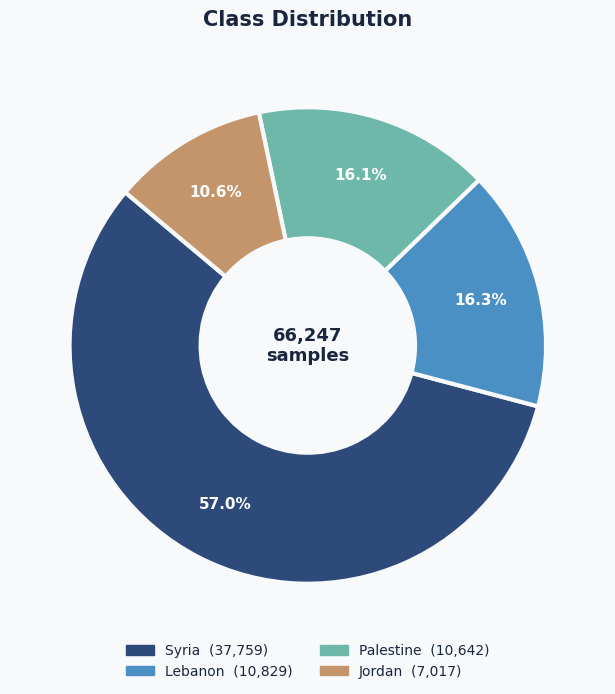

In [8]:
class_dist = df['country'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7), facecolor=BG_COLOR)
wedges, texts, autotexts = ax.pie(
    class_dist,
    labels=None,
    autopct='%1.1f%%',
    startangle=140,
    colors=PALETTE,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor=BG_COLOR, linewidth=3),
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
    at.set_color("white")

# Centre label
ax.text(0, 0, f"{class_dist.sum():,}\nsamples",
        ha='center', va='center', fontsize=13,
        fontweight='bold', color=TEXT_DARK)

# Legend
legend_labels = [f"{c}  ({v:,})" for c, v in class_dist.items()]
patches = [mpatches.Patch(color=PALETTE[i], label=legend_labels[i])
           for i in range(len(class_dist))]
ax.legend(handles=patches, loc="lower center", bbox_to_anchor=(0.5, -0.08),
          ncol=2, frameon=False, fontsize=10)

ax.set_title("Class Distribution", fontsize=15, fontweight='bold',
             color=TEXT_DARK, pad=16)
fig.tight_layout()
global_image("class_distribution")

### Split

In [9]:
X = df[["text", "clean_word", "clean_char"]]
y = df["country"]
 
le          = LabelEncoder()
y_encoded   = le.fit_transform(y)
label_names = le.classes_
label_mapping   = {label: idx  for idx, label in enumerate(label_names)}
class_name_map  = {i: name     for i, name   in enumerate(label_names)}
print("Label mapping:", label_mapping)
 
from collections import Counter
 
def print_class_distribution(y_data, title):
    counter = Counter(y_data)
    print(f"\n=== {title} ===")
    total = len(y_data)
    for cls_id in sorted(counter.keys()):
        cls_name = class_name_map[cls_id]
        count    = counter[cls_id]
        print(f"{cls_id} ({cls_name}) : {count} ({count/total*100:.2f}%)")
    print("Total :", total)
 
print_class_distribution(y_encoded, "BEFORE SPLIT")
 
X_train_full, X_test,  y_train_full, y_test  = train_test_split(
    X, y_encoded, test_size=0.25, stratify=y_encoded, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20,
    stratify=y_train_full, random_state=42)
 
print_class_distribution(y_train, "TRAIN SET")
print_class_distribution(y_val,   "VALIDATION SET")
print_class_distribution(y_test,  "TEST SET")

Label mapping: {'Jordan': 0, 'Lebanon': 1, 'Palestine': 2, 'Syria': 3}

=== BEFORE SPLIT ===
0 (Jordan) : 7017 (10.59%)
1 (Lebanon) : 10829 (16.35%)
2 (Palestine) : 10642 (16.06%)
3 (Syria) : 37759 (57.00%)
Total : 66247

=== TRAIN SET ===
0 (Jordan) : 4210 (10.59%)
1 (Lebanon) : 6498 (16.35%)
2 (Palestine) : 6385 (16.06%)
3 (Syria) : 22655 (57.00%)
Total : 39748

=== VALIDATION SET ===
0 (Jordan) : 1053 (10.60%)
1 (Lebanon) : 1624 (16.34%)
2 (Palestine) : 1596 (16.06%)
3 (Syria) : 5664 (57.00%)
Total : 9937

=== TEST SET ===
0 (Jordan) : 1754 (10.59%)
1 (Lebanon) : 2707 (16.34%)
2 (Palestine) : 2661 (16.07%)
3 (Syria) : 9440 (57.00%)
Total : 16562


## Feature Extraction

In [10]:
CHI2_PCT             = 0.015
MI_PCT23             = 0.010
MI_PCT45             = 0.015
USE_OOF_INTERACTION = True   # flag diteruskan ke ShamiFeatureExtractor
 
split_hash = hashlib.md5(pd.util.hash_pandas_object(X_train["text"]).values).hexdigest()[:10]
base_signature = f"{features.FEATURES_VERSION}_{split_hash}"
base_cache_dir = os.path.join(path_file, "cache", base_signature)
os.makedirs(base_cache_dir, exist_ok=True)
 
feat_cache_key = (
    f"chi2_{CHI2_PCT}_mi23_{MI_PCT23}_mi45_{MI_PCT45}"
    f"_oof_inter_{int(USE_OOF_INTERACTION)}"
)
data_hash = hashlib.md5(df["text"].str.cat().encode()).hexdigest()[:8]

feat_cache_dir = os.path.join(
    base_cache_dir,
    feat_cache_key,
    data_hash
)

os.makedirs(feat_cache_dir, exist_ok=True)
print("Base signature :", base_signature)
print("Feat cache dir :", feat_cache_dir)
 
feat_path = os.path.join(base_cache_dir, "feature_extractor.pkl")
if os.path.exists(feat_path):
    print("✅ Loading base extractor...")
    feat = joblib.load(feat_path)
else:
    print("⚙️ Building base extractor (MI fit bisa makan waktu 2-5 menit)...")
    feat = ShamiFeatureExtractor(
        chi2_pct=CHI2_PCT,
        mi_pct23=MI_PCT23,
        mi_pct45=MI_PCT45,
        use_oof_lr=True,
        use_oof_interaction=USE_OOF_INTERACTION, 
    )
    feat.fit(X_train, y_train) 
    joblib.dump(feat, feat_path)
print("Base extractor ready.")

Base signature : Shami Extractor_0890ac2785
Feat cache dir : cache/Shami Extractor_0890ac2785/chi2_0.015_mi23_0.01_mi45_0.015_oof_inter_1/6ace3dc3
✅ Loading base extractor...


Base extractor ready.


### Update k

In [11]:
feat.update_chi2_pct(CHI2_PCT)
feat.update_mi_pct(new_pct23=MI_PCT23, new_pct45=MI_PCT45)
 
# ---- Info dimensi ----
print("\nMI info     :", feat.mi_info)
print("Block sizes :", feat.block_sizes)

[update] chi2_pct=1.50% -> chi2_k=2,420
[update] mi_pct23=1.00% -> mi_k23=500
[update] mi_pct45=1.50% -> mi_k45=2,650

MI info     : {'chi2_pct': 0.015, 'chi2_k_eff': 2420, 'mi_pct23': 0.01, 'mi_k23_eff': 500, 'char23_vocab': 10964, 'char23_selected': 500, 'mi_pct45': 0.015, 'mi_k45_eff': 2650, 'char45_vocab': 176676, 'char45_selected': 2650}
Block sizes : {'lexical': 2420, 'char_mi23': 500, 'char_mi45': 2650, 'doc_stats': 7, 'stopword': 2, 'morph': 26, 'morph_inter': 8, 'colloc_dom': 1, 'nbsvm': 4, 'oof_lr': 8, 'oof_svm': 8, 'oof_interactions': 10}


### Lexical Info

In [12]:
dims = {
    "tfidf_wL_uni": len(feat.tfidf_wL_uni.vocabulary_),
    "tfidf_wL_23" : len(feat.tfidf_wL_23.vocabulary_),
    "tfidf_wA_uni": len(feat.tfidf_wA_uni.vocabulary_),
    "tfidf_wA_23" : len(feat.tfidf_wA_23.vocabulary_),
    "tfidf_char"  : len(feat.tfidf_char.vocabulary_),
    "bm25_word"   : len(feat.bm25w.cv.vocabulary_),
    "bm25_char"   : len(feat.bm25c.cv.vocabulary_),
}
print("\n==============================")
print("LEXICAL FEATURES BEFORE CHI2")
print("==============================")
for k, v in dims.items():
    print(f"{k:15s}: {v:,}")
print(f"\nLEXICAL total  : {sum(dims.values()):,}")
 
ranges = {}
start  = 0
for name, size in dims.items():
    ranges[name] = (start, start + size)
    start += size
counts = {k: 0 for k in dims}
for c in feat._chi2_cols:
    for name, (s, e) in ranges.items():
        if s <= c < e:
            counts[name] += 1
            break
print("\n==============================")
print("LEXICAL FEATURES AFTER CHI2")
print("==============================")
for k, v in counts.items():
    print(f"{k:15s}: {v:,}")
print(f"\nTotal chi2 selected: {len(feat._chi2_cols):,}")


LEXICAL FEATURES BEFORE CHI2
tfidf_wL_uni   : 19,234
tfidf_wL_23    : 19,234
tfidf_wA_uni   : 19,226
tfidf_wA_23    : 19,226
tfidf_char     : 34,631
bm25_word      : 40,562
bm25_char      : 9,272

LEXICAL total  : 161,385

LEXICAL FEATURES AFTER CHI2
tfidf_wL_uni   : 115
tfidf_wL_23    : 115
tfidf_wA_uni   : 115
tfidf_wA_23    : 115
tfidf_char     : 843
bm25_word      : 316
bm25_char      : 801

Total chi2 selected: 2,420


In [13]:
print("\n==============================")
print("CHAR FEATURES BEFORE MI")
print("==============================")

print(f"char_2_3 vocab: {feat._X_char23_tr.shape[1]:,}")
print(f"char_4_5 vocab: {feat._X_char45_tr.shape[1]:,}")
print(f"Total char    : {feat._X_char23_tr.shape[1] + feat._X_char45_tr.shape[1]:,}")

print("\n==============================")
print("CHAR FEATURES AFTER MI")
print("==============================")

print(f"char_mi23: {feat._mi_sel23.n_selected:,}")
print(f"char_mi45: {feat._mi_sel45.n_selected:,}")
print(f"Total MI  : {feat._mi_sel23.n_selected + feat._mi_sel45.n_selected:,}")


CHAR FEATURES BEFORE MI
char_2_3 vocab: 10,964
char_4_5 vocab: 176,676
Total char    : 187,640

CHAR FEATURES AFTER MI
char_mi23: 500
char_mi45: 2,650
Total MI  : 3,150


### Build / Load Feature Matrices

In [14]:
xtr_path  = os.path.join(feat_cache_dir, "Xtr_feat.pkl")
xval_path = os.path.join(feat_cache_dir, "Xval_feat.pkl")
xte_path  = os.path.join(feat_cache_dir, "Xte_feat.pkl")
ytr_path  = os.path.join(feat_cache_dir, "y_train.pkl")
yval_path = os.path.join(feat_cache_dir, "y_val.pkl")
yte_path  = os.path.join(feat_cache_dir, "y_test.pkl")
 
if all(os.path.exists(p) for p in [xtr_path, xval_path, xte_path,
                                    ytr_path, yval_path, yte_path]):
    print("✅ Loading feature matrices from cache...")
    Xtr_feat  = joblib.load(xtr_path)
    Xval_feat = joblib.load(xval_path)
    Xte_feat  = joblib.load(xte_path)
    y_train   = joblib.load(ytr_path)
    y_val     = joblib.load(yval_path)
    y_test    = joblib.load(yte_path)
else:
    print("⚙️ Building feature matrices...")
    # feat.transform() output:
    # [lexical_chi2 | char_mi23 | char_mi45 | structural | oof_lr | oof_svm | oof_interactions]
    Xtr_feat  = feat.transform(X_train, is_train=True)   
    Xval_feat = feat.transform(X_val,   is_train=False)  
    Xte_feat  = feat.transform(X_test,  is_train=False)  
    gc.collect()
    joblib.dump(Xtr_feat,  xtr_path)
    joblib.dump(Xval_feat, xval_path)
    joblib.dump(Xte_feat,  xte_path)
    joblib.dump(y_train,   ytr_path)
    joblib.dump(y_val,     yval_path)
    joblib.dump(y_test,    yte_path)
 
print(f"Train shape : {Xtr_feat.shape}")
print(f"Val shape   : {Xval_feat.shape}")
print(f"Test shape  : {Xte_feat.shape}")

✅ Loading feature matrices from cache...


Train shape : (39748, 5644)
Val shape   : (9937, 5644)
Test shape  : (16562, 5644)


### Block Ablation Utilities

In [15]:
def build_block_slices(block_sizes):
    slices = {}
    start  = 0
    for name, size in block_sizes.items():
        slices[name] = (start, start + size)
        start += size
    return slices
 
def drop_blocks(X, block_slices, drop_list):
    keep_cols = []
    for name, (s, e) in block_slices.items():
        if name not in drop_list:
            keep_cols.extend(range(s, e))
        else:
            print(f"  Dropping block: {name}  size={e - s:,}")
    keep_cols = np.array(keep_cols)
    return X[:, keep_cols], keep_cols
 
block_slices = build_block_slices(feat.block_sizes)
print("\nBlock slices:")
for k, (s, e) in block_slices.items():
    print(f"  {k:20s}: cols {s:5d}–{e:5d}  ({e - s:,})")


Block slices:
  lexical             : cols     0– 2420  (2,420)
  char_mi23           : cols  2420– 2920  (500)
  char_mi45           : cols  2920– 5570  (2,650)
  doc_stats           : cols  5570– 5577  (7)
  stopword            : cols  5577– 5579  (2)
  morph               : cols  5579– 5605  (26)
  morph_inter         : cols  5605– 5613  (8)
  colloc_dom          : cols  5613– 5614  (1)
  nbsvm               : cols  5614– 5618  (4)
  oof_lr              : cols  5618– 5626  (8)
  oof_svm             : cols  5626– 5634  (8)
  oof_interactions    : cols  5634– 5644  (10)


In [16]:
# ---- Ubah drop_list untuk ablasi ----
drop_list = []
if drop_list:
    print("\nDropping blocks:", drop_list)
    Xtr_sel,  _         = drop_blocks(Xtr_feat,  block_slices, drop_list)
    Xval_sel, _         = drop_blocks(Xval_feat, block_slices, drop_list)
    Xte_sel,  kept_cols = drop_blocks(Xte_feat,  block_slices, drop_list)
else:
    print("\nNo block dropped.")
    Xtr_sel   = Xtr_feat
    Xval_sel  = Xval_feat
    Xte_sel   = Xte_feat
    kept_cols = np.arange(Xtr_feat.shape[1])


No block dropped.


In [17]:
# ============================================================
## SVD (opsional, default OFF)
# ============================================================
USE_SVD = False
if USE_SVD:
    from sklearn.decomposition import TruncatedSVD
    print("\nApplying SVD compression...")
    svd      = TruncatedSVD(n_components=200, random_state=42)
    Xtr_sel  = svd.fit_transform(Xtr_sel)
    Xval_sel = svd.transform(Xval_sel)
    Xte_sel  = svd.transform(Xte_sel)
    print(f"Train: {Xtr_sel.shape}")
else:
    print("Skipping SVD (recommended for LightGBM)")
    print(f"Train: {Xtr_sel.shape}")

Skipping SVD (recommended for LightGBM)
Train: (39748, 5644)


## Modeling

### Class Weights

In [18]:
def class_weights_effective(y, beta=0.999):
    y = np.asarray(y)
    classes, counts = np.unique(y, return_counts=True)
    eff_num = (1 - np.power(beta, counts)) / (1 - beta)
    weights = 1.0 / eff_num
    weights = weights / weights.min()
    return {c: float(w) for c, w in zip(classes, weights)}
 
class_weight_dict = class_weights_effective(y_train, beta=0.999)

### Load Model Best Params

In [19]:
# Load best params kedua model
best_params = joblib.load(
    os.path.join(SAVE_DIR, "lightgbm_original_best_params.pkl"))
print(f"\n✅ LGB best params: {best_params}")


✅ LGB best params: {'num_leaves': 25, 'colsample_bytree': 0.4, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'min_child_samples': 50}


### Final Model Training


In [20]:
model = lgb.LGBMClassifier(
    objective="multiclass", num_class=len(label_names),
    n_estimators=10000, learning_rate=0.01,
    max_depth=7, min_child_weight=1e-3,
    subsample=0.75, subsample_freq=1,
    random_state=42, n_jobs=-1, force_col_wise=True, verbose=-1, class_weight='balanced',
    **best_params
)
print("Training model...")
model.fit(
    Xtr_sel, y_train,
    eval_set=[(Xtr_sel, y_train), (Xval_sel, y_val)],
    eval_metric="multi_logloss",
    callbacks=[
        lgb.early_stopping(stopping_rounds=150, min_delta=1e-4),
        lgb.log_evaluation(100)
    ]
)
print("Best iteration:", model.best_iteration_)

Training model...


Training until validation scores don't improve for 150 rounds


[100]	training's multi_logloss: 0.567091	valid_1's multi_logloss: 0.525297


[200]	training's multi_logloss: 0.406428	valid_1's multi_logloss: 0.379941


[300]	training's multi_logloss: 0.349753	valid_1's multi_logloss: 0.347158


...

[2300]	training's multi_logloss: 0.113034	valid_1's multi_logloss: 0.311166


[2400]	training's multi_logloss: 0.108247	valid_1's multi_logloss: 0.310942


[2500]	training's multi_logloss: 0.103516	valid_1's multi_logloss: 0.310889


Early stopping, best iteration is:
[2405]	training's multi_logloss: 0.108017	valid_1's multi_logloss: 0.310895


Best iteration: 2405


✅ History learning curve berhasil disimpan ke: artifacts/lightgbm_balanced_weighted/docs/lightgbm_balanced_weighted_learning_curve_history.csv


🖼️ Saved: artifacts/lightgbm_balanced_weighted/image/learning_curve_loss.png


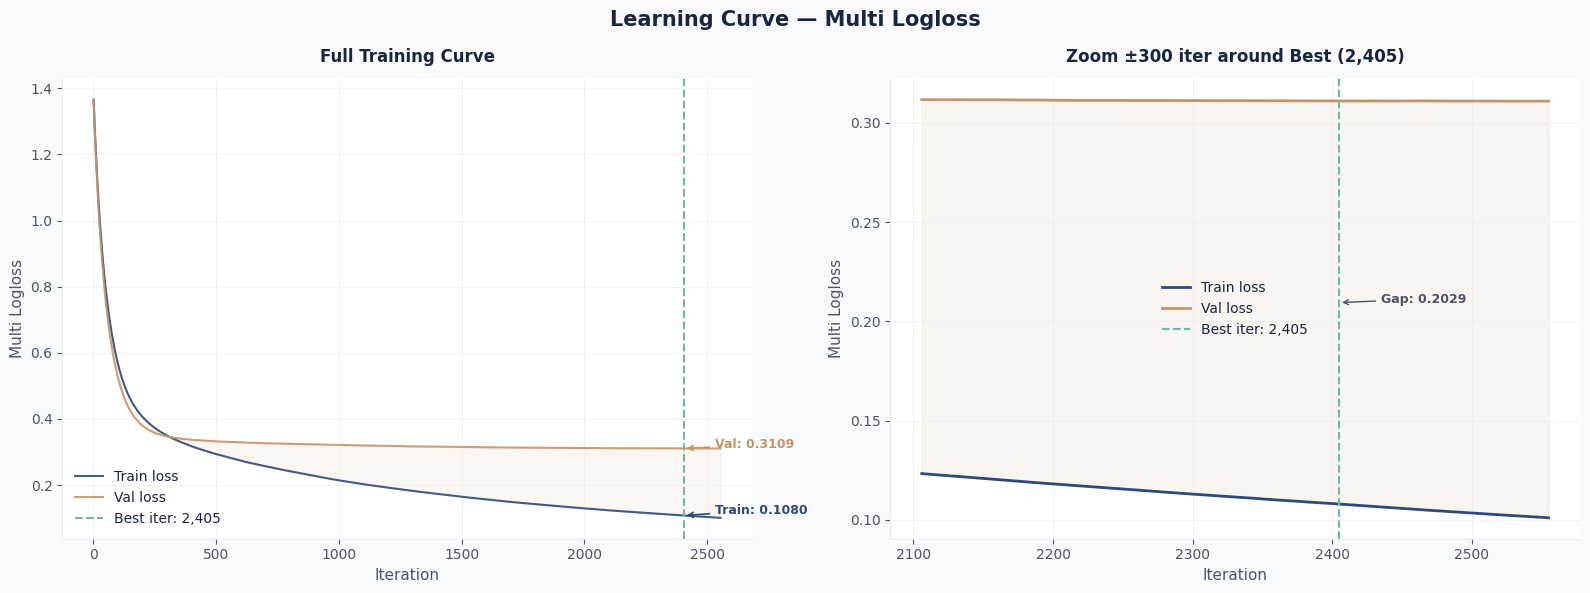

In [21]:
# ── Learning Curve ───────────────────────────────────────────
results  = model.evals_result_
train_loss = results['training']['multi_logloss']
val_loss   = results['valid_1']['multi_logloss']
iterations = range(1, len(train_loss) + 1)
best_iter  = model.best_iteration_

history_df = pd.DataFrame({
    'Iteration': iterations,
    'Train_Multi_Logloss': train_loss,
    'Val_Multi_Logloss': val_loss
})

# Tambahkan penanda (flag) khusus untuk iterasi terbaik
history_df['Is_Best_Iteration'] = history_df['Iteration'] == best_iter

# Simpan ke CSV (menggunakan variabel DOCS_DIR dan KOMPOSISI dari kodemu sebelumnya)
csv_path = os.path.join(DOCS_DIR, f"{KOMPOSISI}_learning_curve_history.csv")
history_df.to_csv(csv_path, index=False)

print(f"✅ History learning curve berhasil disimpan ke: {csv_path}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG_COLOR)
fig.suptitle("Learning Curve — Multi Logloss",
             fontsize=15, fontweight='bold', color=TEXT_DARK)

# ── Kiri: full curve ─────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(CARD_COLOR)

ax.plot(iterations, train_loss,
        color="#2D4A7A", linewidth=1.5,
        label="Train loss", alpha=0.9)
ax.plot(iterations, val_loss,
        color="#C4956A", linewidth=1.5,
        label="Val loss", alpha=0.9)

# shading gap antara train dan val
ax.fill_between(iterations, train_loss, val_loss,
                alpha=0.08, color="#C4956A")

# best iteration line
ax.axvline(best_iter, color="#6DB8A8", linewidth=1.5,
           linestyle="--", label=f"Best iter: {best_iter:,}")

# annotasi nilai loss di best iter
ax.annotate(
    f"Val: {val_loss[best_iter-1]:.4f}",
    xy=(best_iter, val_loss[best_iter-1]),
    xytext=(best_iter + len(iterations)*0.05, val_loss[best_iter-1]),
    fontsize=9, color="#C4956A", fontweight='bold',
    arrowprops=dict(arrowstyle='->', color="#C4956A", lw=1.2),
)
ax.annotate(
    f"Train: {train_loss[best_iter-1]:.4f}",
    xy=(best_iter, train_loss[best_iter-1]),
    xytext=(best_iter + len(iterations)*0.05, train_loss[best_iter-1]*1.05),
    fontsize=9, color="#2D4A7A", fontweight='bold',
    arrowprops=dict(arrowstyle='->', color="#2D4A7A", lw=1.2),
)

ax.set_xlabel("Iteration",       fontsize=11, color=TEXT_MID)
ax.set_ylabel("Multi Logloss",   fontsize=11, color=TEXT_MID)
ax.set_title("Full Training Curve", fontsize=12,
             fontweight='bold', color=TEXT_DARK)
ax.legend(frameon=False, fontsize=10)
ax.grid(color=GRID_COLOR, linewidth=0.6)
ax.spines[['top','right']].set_visible(False)

# ── Kanan: zoom di sekitar best iteration ────────────────────
ax2 = axes[1]
ax2.set_facecolor(CARD_COLOR)

zoom_start = max(0, best_iter - 300)
zoom_end   = min(len(train_loss), best_iter + 300)
iters_zoom = range(zoom_start + 1, zoom_end + 1)

ax2.plot(iters_zoom, train_loss[zoom_start:zoom_end],
         color="#2D4A7A", linewidth=2, label="Train loss")
ax2.plot(iters_zoom, val_loss[zoom_start:zoom_end],
         color="#C4956A", linewidth=2, label="Val loss")
ax2.fill_between(iters_zoom,
                 train_loss[zoom_start:zoom_end],
                 val_loss[zoom_start:zoom_end],
                 alpha=0.1, color="#C4956A")
ax2.axvline(best_iter, color="#6DB8A8", linewidth=1.5,
            linestyle="--", label=f"Best iter: {best_iter:,}")

# gap label
gap = val_loss[best_iter-1] - train_loss[best_iter-1]
ax2.annotate(
    f"Gap: {gap:.4f}",
    xy=(best_iter, (val_loss[best_iter-1] + train_loss[best_iter-1]) / 2),
    xytext=(best_iter + 30, (val_loss[best_iter-1] + train_loss[best_iter-1]) / 2),
    fontsize=9, color=TEXT_MID, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=TEXT_MID, lw=1.0),
)

ax2.set_xlabel("Iteration",     fontsize=11, color=TEXT_MID)
ax2.set_ylabel("Multi Logloss", fontsize=11, color=TEXT_MID)
ax2.set_title(f"Zoom ±300 iter around Best ({best_iter:,})",
              fontsize=12, fontweight='bold', color=TEXT_DARK)
ax2.legend(frameon=False, fontsize=10)
ax2.grid(color=GRID_COLOR, linewidth=0.6)
ax2.spines[['top','right']].set_visible(False)

fig.tight_layout()
save_and_show("learning_curve_loss")

🖼️ Saved: artifacts/lightgbm_balanced_weighted/image/learning_curve_full.png


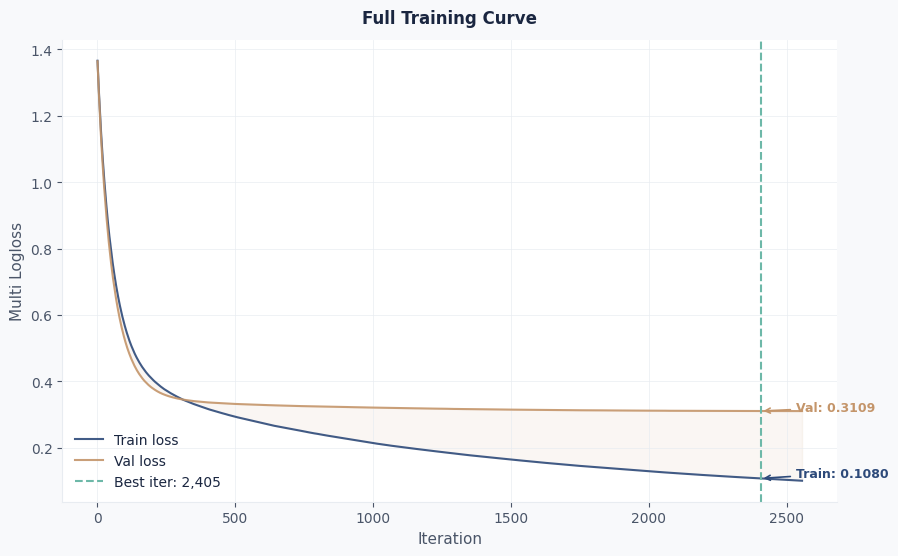

🖼️ Saved: artifacts/lightgbm_balanced_weighted/image/learning_curve_zoom.png


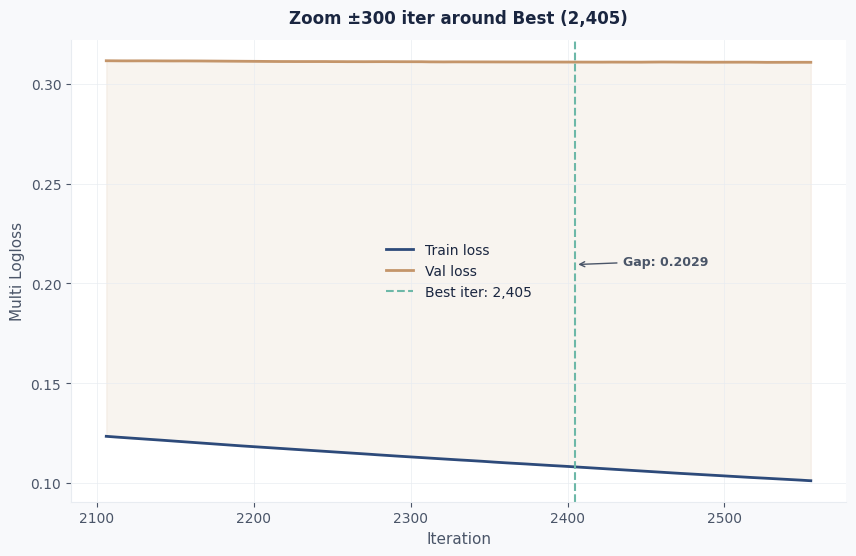


=== LEARNING CURVE SUMMARY ===
Total iterations trained : 2,555
Best iteration           : 2,405
Train loss @ best        : 0.1080
Val   loss @ best        : 0.3109
Gap (val - train)        : 0.2029
Early stop saved iters   : 150


In [22]:
# ── Learning Curve ───────────────────────────────────────────
plt.figure(figsize=(10, 6), facecolor=BG_COLOR)
ax = plt.gca()
ax.set_facecolor(CARD_COLOR)

plt.plot(iterations, train_loss,
         color="#2D4A7A", linewidth=1.5,
         label="Train loss", alpha=0.9)
plt.plot(iterations, val_loss,
         color="#C4956A", linewidth=1.5,
         label="Val loss", alpha=0.9)

plt.fill_between(iterations, train_loss, val_loss,
                 alpha=0.08, color="#C4956A")

plt.axvline(best_iter, color="#6DB8A8", linewidth=1.5,
            linestyle="--", label=f"Best iter: {best_iter:,}")

# annotasi
plt.annotate(
    f"Val: {val_loss[best_iter-1]:.4f}",
    xy=(best_iter, val_loss[best_iter-1]),
    xytext=(best_iter + len(iterations)*0.05, val_loss[best_iter-1]),
    fontsize=9, color="#C4956A", fontweight='bold',
    arrowprops=dict(arrowstyle='->', color="#C4956A", lw=1.2),
)
plt.annotate(
    f"Train: {train_loss[best_iter-1]:.4f}",
    xy=(best_iter, train_loss[best_iter-1]),
    xytext=(best_iter + len(iterations)*0.05, train_loss[best_iter-1]*1.05),
    fontsize=9, color="#2D4A7A", fontweight='bold',
    arrowprops=dict(arrowstyle='->', color="#2D4A7A", lw=1.2),
)

plt.xlabel("Iteration", fontsize=11, color=TEXT_MID)
plt.ylabel("Multi Logloss", fontsize=11, color=TEXT_MID)
plt.title("Full Training Curve", fontsize=12,
          fontweight='bold', color=TEXT_DARK)

plt.legend(frameon=False)
plt.grid(color=GRID_COLOR, linewidth=0.6)
ax.spines[['top','right']].set_visible(False)

save_and_show("learning_curve_full")

plt.figure(figsize=(10, 6), facecolor=BG_COLOR)
ax = plt.gca()
ax.set_facecolor(CARD_COLOR)

zoom_start = max(0, best_iter - 300)
zoom_end   = min(len(train_loss), best_iter + 300)
iters_zoom = range(zoom_start + 1, zoom_end + 1)

plt.plot(iters_zoom, train_loss[zoom_start:zoom_end],
         color="#2D4A7A", linewidth=2, label="Train loss")
plt.plot(iters_zoom, val_loss[zoom_start:zoom_end],
         color="#C4956A", linewidth=2, label="Val loss")

plt.fill_between(iters_zoom,
                 train_loss[zoom_start:zoom_end],
                 val_loss[zoom_start:zoom_end],
                 alpha=0.1, color="#C4956A")

plt.axvline(best_iter, color="#6DB8A8", linewidth=1.5,
            linestyle="--", label=f"Best iter: {best_iter:,}")

# gap annotation
gap = val_loss[best_iter-1] - train_loss[best_iter-1]
plt.annotate(
    f"Gap: {gap:.4f}",
    xy=(best_iter, (val_loss[best_iter-1] + train_loss[best_iter-1]) / 2),
    xytext=(best_iter + 30, (val_loss[best_iter-1] + train_loss[best_iter-1]) / 2),
    fontsize=9, color=TEXT_MID, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=TEXT_MID, lw=1.0),
)

plt.xlabel("Iteration", fontsize=11, color=TEXT_MID)
plt.ylabel("Multi Logloss", fontsize=11, color=TEXT_MID)
plt.title(f"Zoom ±300 iter around Best ({best_iter:,})",
          fontsize=12, fontweight='bold', color=TEXT_DARK)

plt.legend(frameon=False)
plt.grid(color=GRID_COLOR, linewidth=0.6)
ax.spines[['top','right']].set_visible(False)

save_and_show("learning_curve_zoom")

# ── Summary stats ────────────────────────────────────────────
print(f"\n=== LEARNING CURVE SUMMARY ===")
print(f"Total iterations trained : {len(train_loss):,}")
print(f"Best iteration           : {best_iter:,}")
print(f"Train loss @ best        : {train_loss[best_iter-1]:.4f}")
print(f"Val   loss @ best        : {val_loss[best_iter-1]:.4f}")
print(f"Gap (val - train)        : {val_loss[best_iter-1] - train_loss[best_iter-1]:.4f}")
print(f"Early stop saved iters   : {len(train_loss) - best_iter:,}")

## Save Artifacts

In [23]:
print("💾 Menyimpan artifacts modeling...")

joblib.dump(model, os.path.join(MODEL_DIR, f"model_{KOMPOSISI}.pkl"))

print("✅ Artifacts modeling berhasil disimpan!")

💾 Menyimpan artifacts modeling...


✅ Artifacts modeling berhasil disimpan!


## Evaluation & Analysis

### Evaluation Report

In [24]:
def evaluate_split(name, y_true, y_pred):
    print(f"\n===== {name} =====")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Macro F1 :", f1_score(y_true, y_pred, average="macro"))
    print(classification_report(y_true, y_pred, target_names=label_names, digits=4))
 
for split_name, X_sp, y_sp in [
    ("TRAIN", Xtr_sel,  y_train),
    ("VAL",   Xval_sel, y_val),
    ("TEST",  Xte_sel,  y_test),
]:
    evaluate_split(split_name, y_sp,
                   model.predict(X_sp, num_iteration=model.best_iteration_))
 
cm    = confusion_matrix(y_test, model.predict(Xte_sel, num_iteration=model.best_iteration_))
cm_df = pd.DataFrame(cm, index=label_names, columns=label_names)
print("\nConfusion Matrix:\n", cm_df)


===== TRAIN =====
Accuracy : 0.9770554493307839
Macro F1 : 0.9732631392202623
              precision    recall  f1-score   support

      Jordan     0.9411    0.9974    0.9684      4210
     Lebanon     0.9455    0.9906    0.9675      6498
   Palestine     0.9613    0.9889    0.9749      6385
       Syria     0.9989    0.9661    0.9822     22655

    accuracy                         0.9771     39748
   macro avg     0.9617    0.9857    0.9733     39748
weighted avg     0.9780    0.9771    0.9772     39748




===== VAL =====
Accuracy : 0.892019724262856
Macro F1 : 0.8472234450039682
              precision    recall  f1-score   support

      Jordan     0.7599    0.7664    0.7631      1053
     Lebanon     0.8293    0.8615    0.8451      1624
   Palestine     0.8120    0.8553    0.8331      1596
       Syria     0.9611    0.9345    0.9476      5664

    accuracy                         0.8920      9937
   macro avg     0.8406    0.8544    0.8472      9937
weighted avg     0.8943    0.8920    0.8929      9937




===== TEST =====
Accuracy : 0.8931288491728052
Macro F1 : 0.8501869841414039
              precision    recall  f1-score   support

      Jordan     0.7771    0.7930    0.7850      1754
     Lebanon     0.8196    0.8593    0.8390      2707
   Palestine     0.8128    0.8437    0.8280      2661
       Syria     0.9627    0.9354    0.9489      9440

    accuracy                         0.8931     16562
   macro avg     0.8431    0.8578    0.8502     16562
weighted avg     0.8956    0.8931    0.8941     16562




Confusion Matrix:
            Jordan  Lebanon  Palestine  Syria
Jordan       1391       88        174    101
Lebanon        95     2326        142    144
Palestine     140      179       2245     97
Syria         164      245        201   8830


### Confusion matrix heatmap

🖼️ Saved: artifacts/lightgbm_balanced_weighted/image/confusion_matrix.png


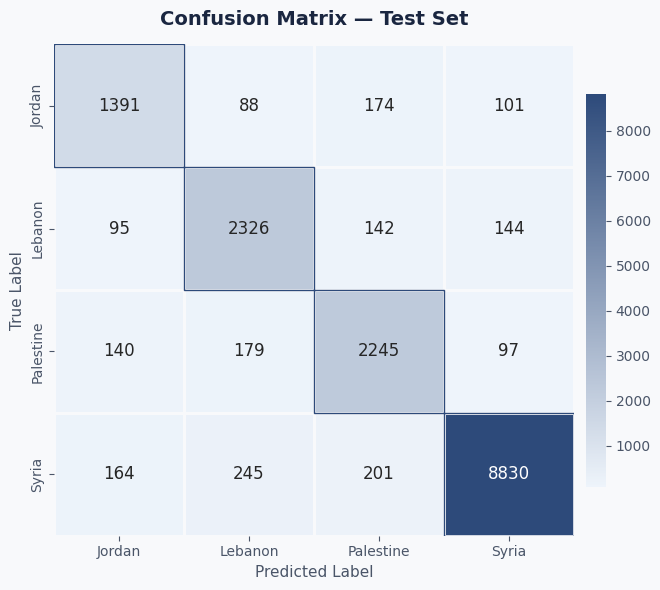


=== SUMMARY ===
Train F1 : 0.9733
Val F1   : 0.8472
Test F1  : 0.8502
Gap T-V  : 0.1260  ⚠ overfit
Gap V-Te : 0.0030  ✓ generalize baik


In [25]:
# ── 2. Confusion Matrix ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG_COLOR)

cmap = LinearSegmentedColormap.from_list(
    "custom_blue", ["#EEF4FB", "#2D4A7A"], N=256)

sns.heatmap(
    cm_df, annot=True, fmt='d', cmap=cmap,
    linewidths=2, linecolor=BG_COLOR,
    annot_kws={"size": 12},
    ax=ax, cbar_kws={"shrink": 0.8, "pad": 0.02}
)

ax.grid(False)

# Highlight diagonal
for i in range(len(cm_df)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1,
                 fill=False, edgecolor="#2D4A7A", lw=1))

ax.set_title("Confusion Matrix — Test Set",
             fontsize=14, fontweight='bold', color=TEXT_DARK, pad=14)
ax.set_ylabel("True Label",     fontsize=11, color=TEXT_MID)
ax.set_xlabel("Predicted Label", fontsize=11, color=TEXT_MID)
ax.tick_params(axis='both', labelsize=10)
ax.figure.facecolor = BG_COLOR

fig.tight_layout()
save_and_show("confusion_matrix")


f1_tr  = f1_score(y_train, model.predict(Xtr_sel,  num_iteration=model.best_iteration_), average="macro")
f1_val = f1_score(y_val,   model.predict(Xval_sel, num_iteration=model.best_iteration_), average="macro")
f1_te  = f1_score(y_test,  model.predict(Xte_sel,  num_iteration=model.best_iteration_), average="macro")
print(f"\n=== SUMMARY ===")
print(f"Train F1 : {f1_tr:.4f}")
print(f"Val F1   : {f1_val:.4f}")
print(f"Test F1  : {f1_te:.4f}")
print(f"Gap T-V  : {f1_tr - f1_val:.4f}  {'⚠ overfit' if f1_tr - f1_val > 0.10 else '✓ ok'}")
print(f"Gap V-Te : {abs(f1_val - f1_te):.4f}  {'✓ generalize baik' if abs(f1_val - f1_te) < 0.01 else '△ cek'}")
 

### Feature Importance per Block

🖼️ Saved: artifacts/lightgbm_balanced_weighted/image/feature_importance_total.png


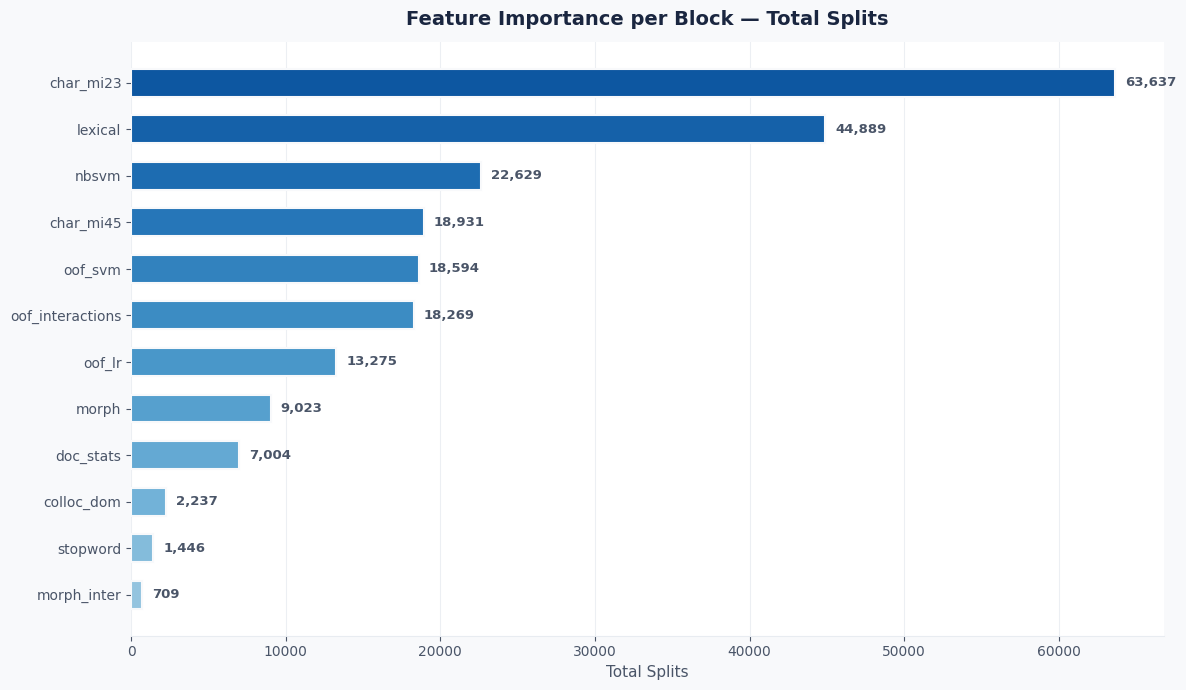

   Feature_Block  Total_Importance  Average_Importance_per_Col  Cols
       char_mi23             63637                  127.274000   500
         lexical             44889                   18.549174  2420
           nbsvm             22629                 5657.250000     4
       char_mi45             18931                    7.143774  2650
         oof_svm             18594                 2324.250000     8
oof_interactions             18269                 1826.900000    10
          oof_lr             13275                 1659.375000     8
           morph              9023                  347.038462    26
       doc_stats              7004                 1000.571429     7
      colloc_dom              2237                 2237.000000     1
        stopword              1446                  723.000000     2
     morph_inter               709                   88.625000     8


In [26]:
importances  = model.feature_importances_
block_slices_imp = build_block_slices(feat.block_sizes)
 
block_importance = {}
for name, (s, e) in block_slices_imp.items():
    if name in drop_list or s >= len(importances):
        continue
    end_idx  = min(e, len(importances))
    blk_imp  = importances[s:end_idx]
    if len(blk_imp) == 0:
        continue
    block_importance[name] = {
        'Total_Importance'          : blk_imp.sum(),
        'Average_Importance_per_Col': blk_imp.mean(),
        'Cols'                      : len(blk_imp),
    }
 
df_imp = (
    pd.DataFrame.from_dict(block_importance, orient='index')
      .reset_index().rename(columns={'index': 'Feature_Block'})
      .sort_values('Total_Importance', ascending=False)
)
 
fig, ax = plt.subplots(figsize=(12, 7), facecolor=BG_COLOR)
ax.set_facecolor(CARD_COLOR)

n      = len(df_imp)
colors = plt.cm.Blues(np.linspace(0.4, 0.85, n))[::-1]

bars = ax.barh(df_imp['Feature_Block'], df_imp['Total_Importance'],
               color=colors, edgecolor=BG_COLOR, linewidth=1.5, height=0.6)

# Value labels
for bar, val in zip(bars, df_imp['Total_Importance']):
    ax.text(bar.get_width() + df_imp['Total_Importance'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{int(val):,}", va='center', ha='left',
            fontsize=9.5, color=TEXT_MID, fontweight='bold')

ax.set_xlabel("Total Splits", fontsize=11, color=TEXT_MID)
ax.set_ylabel("")
ax.set_title("Feature Importance per Block — Total Splits",
             fontsize=14, fontweight='bold', color=TEXT_DARK)
ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.8)
ax.yaxis.grid(False)
ax.set_axisbelow(True)
ax.spines['left'].set_visible(False)

ax.invert_yaxis()

fig.tight_layout()
save_and_show("feature_importance_total")

print(df_imp.to_string(index=False))

### Average importance per column

🖼️ Saved: artifacts/lightgbm_balanced_weighted/image/feature_importance_avg.png


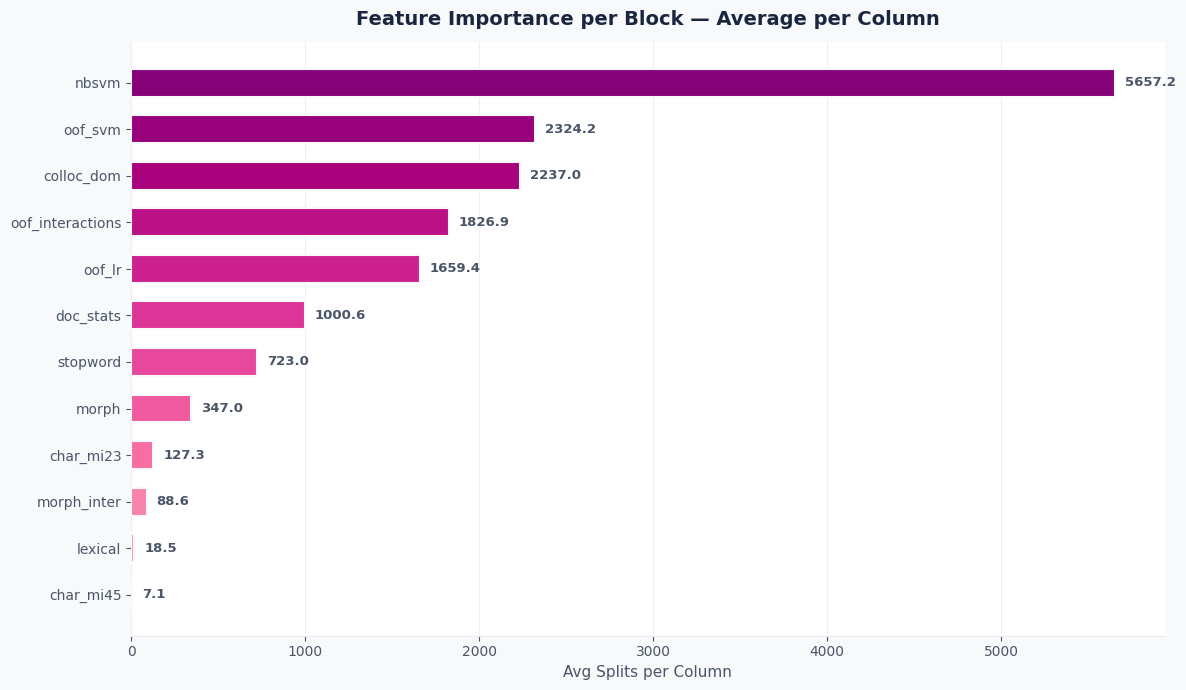

In [27]:
df_imp_avg = df_imp.sort_values('Average_Importance_per_Col', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7), facecolor=BG_COLOR)
ax.set_facecolor(CARD_COLOR)

n      = len(df_imp_avg)
colors = plt.cm.RdPu(np.linspace(0.35, 0.85, n))[::-1]

bars = ax.barh(df_imp_avg['Feature_Block'],
               df_imp_avg['Average_Importance_per_Col'],
               color=colors, edgecolor=BG_COLOR, linewidth=1.5, height=0.6)

for bar, val in zip(bars, df_imp_avg['Average_Importance_per_Col']):
    ax.text(bar.get_width() + df_imp_avg['Average_Importance_per_Col'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}", va='center', ha='left',
            fontsize=9.5, color=TEXT_MID, fontweight='bold')

ax.set_xlabel("Avg Splits per Column", fontsize=11, color=TEXT_MID)
ax.set_ylabel("")
ax.set_title("Feature Importance per Block — Average per Column",
             fontsize=14, fontweight='bold', color=TEXT_DARK)
ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.8)
ax.yaxis.grid(False)
ax.set_axisbelow(True)
ax.spines['left'].set_visible(False)

ax.invert_yaxis()

fig.tight_layout()
save_and_show("feature_importance_avg")

### Error Analysis

In [28]:
print("\nGenerating Error Analysis...")
test_proba   = model.predict_proba(Xte_sel, num_iteration=model.best_iteration_)
y_pred_final = model.predict(Xte_sel, num_iteration=model.best_iteration_)
label_list   = list(label_names)
idx_jo = label_list.index("Jordan")
idx_le = label_list.index("Lebanon")
idx_pa = label_list.index("Palestine")
idx_sy = label_list.index("Syria")
 
df_export = pd.DataFrame({
    "text"          : X_test["text"].values,
    "clean_word"    : X_test["clean_word"].values,
    "true_label"    : [label_names[i] for i in y_test],
    "pred_label"    : [label_names[i] for i in y_pred_final],
    "correct"       : (y_test == y_pred_final),
    "confidence"    : np.max(test_proba, axis=1).round(4),
    "conf_jordan"   : test_proba[:, idx_jo].round(4),
    "conf_lebanon"  : test_proba[:, idx_le].round(4),
    "conf_palestine": test_proba[:, idx_pa].round(4),
    "conf_syria"    : test_proba[:, idx_sy].round(4),
    "text_len"      : X_test["text"].str.len().values,
    "n_words"       : X_test["text"].str.split().str.len().values,
    # Fitur tambahan untuk analisis tesis
    "entropy"       : (-test_proba * np.log(test_proba + 1e-9)).sum(axis=1).round(4),
    "margin"        : (np.sort(test_proba, axis=1)[:, -1]
                       - np.sort(test_proba, axis=1)[:, -2]).round(4),
})
 
def categorize(row):
    if row["correct"]:           return "correct"
    if row["n_words"] <= 4:      return "too_short_<=4w"
    if row["text_len"] < 30:     return "too_short_<30c"
    if row["confidence"] > 0.85: return "high_conf_wrong"
    if row["confidence"] < 0.45: return "low_conf_ambiguous"
    return "medium_conf_wrong"
 
df_export["error_category"] = df_export.apply(categorize, axis=1)
df_export.to_csv(os.path.join(DOCS_DIR, f"{KOMPOSISI}_error_analysis_full.csv"),
                 index=False, encoding="utf-8-sig")
print(f"Saved: {KOMPOSISI}_error_analysis_full.csv ({len(df_export)} rows)")
 
df_errors = (
    df_export[~df_export["correct"]]
    .sort_values(["true_label", "pred_label", "confidence"],
                 ascending=[True, True, False])
)
df_errors.to_csv(os.path.join(DOCS_DIR, f"{KOMPOSISI}_error_analysis_errors_only.csv"),
                 index=False, encoding="utf-8-sig")
print(f"Saved: {KOMPOSISI}_error_analysis_errors_only.csv ({len(df_errors)} rows)")
 
summary = (
    df_errors.groupby(["true_label", "pred_label", "error_category"])
             .size().reset_index(name="count")
             .sort_values("count", ascending=False)
)
print("\n=== RINGKASAN ERROR ===")
print(summary.to_string(index=False))
print("\n=== DISTRIBUSI KATEGORI ===")
print(df_errors["error_category"].value_counts().to_string())


Generating Error Analysis...


Saved: lightgbm_balanced_weighted_error_analysis_full.csv (16562 rows)
Saved: lightgbm_balanced_weighted_error_analysis_errors_only.csv (1770 rows)

=== RINGKASAN ERROR ===
true_label pred_label     error_category  count
     Syria     Jordan  medium_conf_wrong     91
     Syria  Palestine  medium_conf_wrong     88
    Jordan  Palestine  medium_conf_wrong     80
     Syria    Lebanon  medium_conf_wrong     76
   Lebanon  Palestine  medium_conf_wrong     66
 Palestine     Jordan  medium_conf_wrong     66
 Palestine    Lebanon  medium_conf_wrong     64
     Syria    Lebanon     too_short_<30c     62
     Syria    Lebanon     too_short_<=4w     60
   Lebanon      Syria  medium_conf_wrong     57
 Palestine      Syria  medium_conf_wrong     48
 Palestine    Lebanon     too_short_<30c     45
   Lebanon     Jordan  medium_conf_wrong     43
 Palestine    Lebanon     too_short_<=4w     42
    Jordan  Palestine    high_conf_wrong     40
    Jordan    Lebanon  medium_conf_wrong     38
     Syria 

🖼️ Saved: artifacts/lightgbm_balanced_weighted/image/confidence_distribution.png


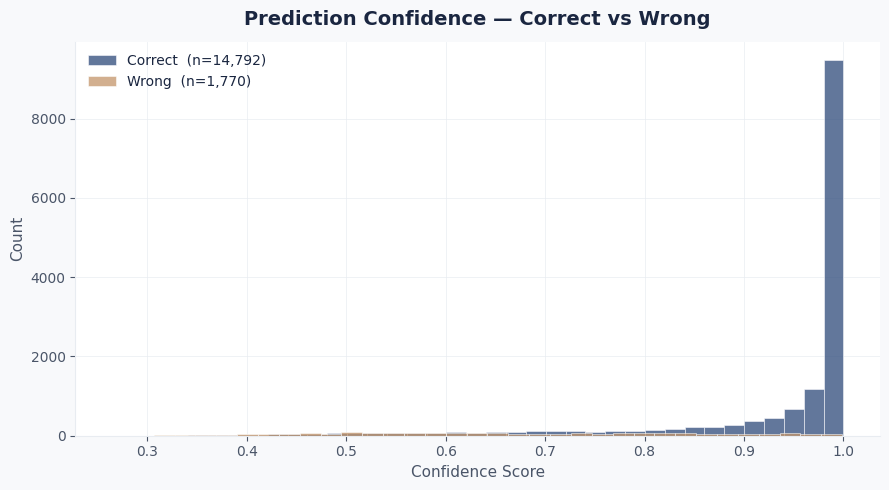

🖼️ Saved: artifacts/lightgbm_balanced_weighted/image/entropy_per_class.png


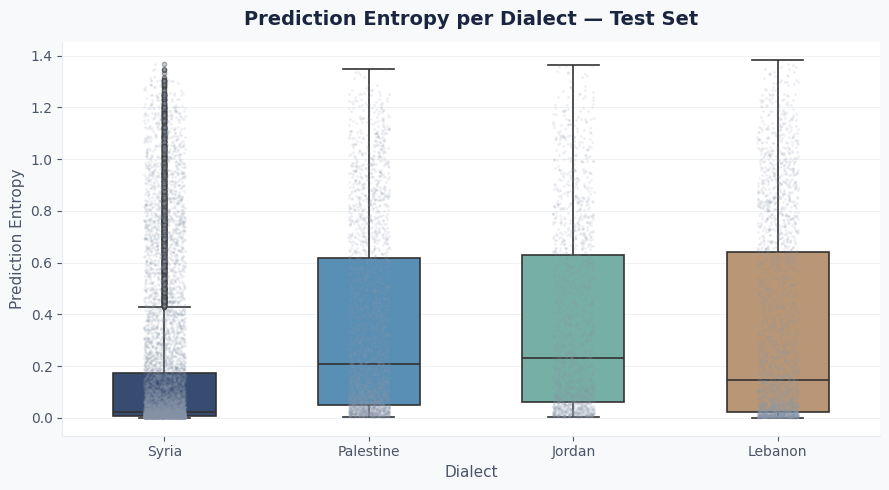

🖼️ Saved: artifacts/lightgbm_balanced_weighted/image/margin_analysis.png


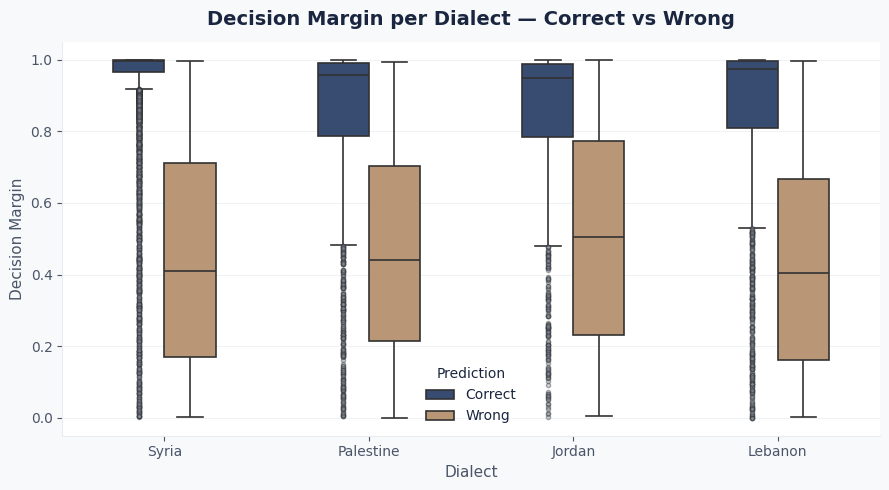

In [29]:
# ── Confidence Distribution ───────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG_COLOR)
ax.set_facecolor(CARD_COLOR)

for correct, color, label in [
    (True,  "#2D4A7A", "Correct"),
    (False, "#C4956A", "Wrong"),
]:
    subset = df_export[df_export["correct"] == correct]["confidence"]
    ax.hist(subset, bins=35, alpha=0.75, color=color,
            label=f"{label}  (n={len(subset):,})",
            edgecolor="white", linewidth=0.5)

ax.set_xlabel("Confidence Score", fontsize=11, color=TEXT_MID)
ax.set_ylabel("Count",            fontsize=11, color=TEXT_MID)
ax.set_title("Prediction Confidence — Correct vs Wrong",
             fontsize=14, fontweight='bold', color=TEXT_DARK)
ax.legend(frameon=False, fontsize=10)
ax.yaxis.grid(True, color=GRID_COLOR)
ax.set_axisbelow(True)

fig.tight_layout()
save_and_show("confidence_distribution")


# ── Entropy per Class ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG_COLOR)
ax.set_facecolor(CARD_COLOR)

sns.boxplot(
    x="true_label", y="entropy", data=df_export,
    palette=PALETTE, width=0.5, linewidth=1.2,
    flierprops=dict(marker='o', markerfacecolor=TEXT_LIGHT,
                    markersize=3, alpha=0.4, linestyle='none'),
    ax=ax
)
sns.stripplot(
    x="true_label", y="entropy", data=df_export,
    color=TEXT_LIGHT, alpha=0.15, size=2, jitter=True, ax=ax
)

ax.set_xlabel("Dialect", fontsize=11, color=TEXT_MID)
ax.set_ylabel("Prediction Entropy", fontsize=11, color=TEXT_MID)
ax.set_title("Prediction Entropy per Dialect — Test Set",
             fontsize=14, fontweight='bold', color=TEXT_DARK)
ax.yaxis.grid(True, color=GRID_COLOR)
ax.set_axisbelow(True)

fig.tight_layout()
save_and_show("entropy_per_class")


# ── Margin Analysis ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG_COLOR)
ax.set_facecolor(CARD_COLOR)

sns.boxplot(
    x="true_label", y="margin", hue="correct",
    data=df_export,
    palette={True: "#2D4A7A", False: "#C4956A"},  # ← boolean, bukan string
    hue_order=[True, False],
    width=0.5, linewidth=1.2,
    flierprops=dict(marker='o', markerfacecolor=TEXT_LIGHT,
                    markersize=3, alpha=0.4, linestyle='none'),
    ax=ax
)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Correct", "Wrong"],
          frameon=False, fontsize=10, title="Prediction")

ax.set_xlabel("Dialect",         fontsize=11, color=TEXT_MID)
ax.set_ylabel("Decision Margin", fontsize=11, color=TEXT_MID)
ax.set_title("Decision Margin per Dialect — Correct vs Wrong",
             fontsize=14, fontweight='bold', color=TEXT_DARK)
ax.yaxis.grid(True, color=GRID_COLOR)
ax.set_axisbelow(True)

fig.tight_layout()
save_and_show("margin_analysis")

### Lexical Exclusivity Analysis (Jordan, Palestine, Syria/Lebanon)

In [30]:
def exclusivity_analysis(df_src, df_all, src_label,
                         top_n=40, min_freq=10, ratio_thresh=4.0):
    """Token yang paling eksklusif di src_label vs semua negara lain."""
    df_others = df_all[df_all['true_label'] != src_label]
    src_tok, oth_tok = Counter(), Counter()
    for t in df_src['clean_word'].dropna():    src_tok.update(str(t).split())
    for t in df_others['clean_word'].dropna(): oth_tok.update(str(t).split())
    n_src, n_oth = len(df_src), len(df_others)
    results = []
    for tok, cnt_s in src_tok.most_common(500):
        if cnt_s < min_freq or len(tok) < 2: continue
        cnt_o = oth_tok.get(tok, 0)
        ratio = (cnt_s / n_src) / ((cnt_o / n_oth) + 1e-6)
        if ratio > ratio_thresh:
            results.append((tok, cnt_s, cnt_o, ratio))
    results.sort(key=lambda x: -x[3])
    print(f"\n=== TOKEN EKSKLUSIF {src_label.upper()} (vs semua) ===")
    print(f"{'Token':15} | {'Freq':8} | {'Freq Lain':10} | {'Rasio':8}")
    print("-" * 50)
    for tok, cs, co, r in results[:top_n]:
        label_str = "MUTLAK" if co == 0 else f"{r:.1f}x"
        print(f"  {tok:15s} | {cs:<8d} | {co:<10d} | {label_str}")
    return results
 
# Jordan, Palestine — vs semua negara lain
for country in ["Jordan", "Palestine"]:
    df_country = df_export[df_export['true_label'] == country]
    exclusivity_analysis(df_country, df_export, country)
 
# Syria vs Lebanon (head-to-head, bukan vs semua — pasangan paling mirip)
def headtohead_exclusivity(df_src, df_cmp, src_label, cmp_label,
                            top_n=15, min_freq=20, ratio_thresh=5.0):
    src_tok, cmp_tok = Counter(), Counter()
    for t in df_src['clean_word'].dropna(): src_tok.update(str(t).split())
    for t in df_cmp['clean_word'].dropna(): cmp_tok.update(str(t).split())
    n_s, n_c = len(df_src), len(df_cmp)
    excl = []
    for tok, cnt in src_tok.most_common(500):
        if cnt < min_freq or len(tok) < 2: continue
        r = (cnt / n_s) / ((cmp_tok.get(tok, 0) / n_c) + 1e-6)
        if r > ratio_thresh:
            excl.append((tok, cnt, cmp_tok.get(tok, 0), r))
    excl.sort(key=lambda x: -x[3])
    print(f"\n=== TOKEN KHAS {src_label.upper()} VS {cmp_label.upper()} ===")
    print(f"{'Token':15} | {'Freq Src':10} | {'Freq Cmp':10} | {'Rasio':8}")
    print("-" * 52)
    for tok, cs, cc, r in excl[:top_n]:
        print(f"  {tok:15s} | {cs:<10d} | {cc:<10d} | {r:.1f}x")
    return excl
 
df_syria   = df_export[df_export['true_label'] == 'Syria']
df_lebanon = df_export[df_export['true_label'] == 'Lebanon']
headtohead_exclusivity(df_syria,   df_lebanon, "Suriah",  "Lebanon")
headtohead_exclusivity(df_lebanon, df_syria,   "Lebanon", "Suriah")
 


=== TOKEN EKSKLUSIF JORDAN (vs semua) ===
Token           | Freq     | Freq Lain  | Rasio   
--------------------------------------------------
  يزم             | 10       | 0          | MUTLAK
  هسا             | 27       | 1          | 224.6x
  ونا             | 20       | 1          | 166.4x
  ولله            | 14       | 1          | 116.5x
  انتا            | 37       | 3          | 103.6x
  بالحاره         | 11       | 1          | 91.5x
  ولكو            | 10       | 1          | 83.2x
  همه             | 17       | 2          | 71.2x
  حكالي           | 28       | 5          | 47.1x
  حكيتلو          | 11       | 2          | 46.1x
  مهر             | 11       | 2          | 46.1x
  وجهي            | 31       | 6          | 43.5x
  ابوي            | 21       | 5          | 35.4x
  كلشي            | 15       | 4          | 31.5x
  اخوي            | 24       | 7          | 28.9x
  طب              | 47       | 14         | 28.3x
  خصوصي           | 10       | 3          | 28.0x



=== TOKEN EKSKLUSIF PALESTINE (vs semua) ===
Token           | Freq     | Freq Lain  | Rasio   
--------------------------------------------------
  معجنات          | 28       | 0          | MUTLAK
  بجد             | 21       | 0          | MUTLAK
  حماس            | 20       | 0          | MUTLAK
  هما             | 17       | 0          | MUTLAK
  بغزه            | 16       | 0          | MUTLAK
  وتمر            | 16       | 0          | MUTLAK
  الكنه           | 16       | 0          | MUTLAK
  وبالاخر         | 11       | 0          | MUTLAK
  طنشي            | 11       | 0          | MUTLAK
  بتكوني          | 10       | 0          | MUTLAK
  غزه             | 56       | 1          | 288.5x
  زوجك            | 39       | 1          | 200.9x
  هادا            | 37       | 1          | 190.6x
  علشان           | 17       | 1          | 87.6x
  زيك             | 16       | 1          | 82.4x
  حماتك           | 15       | 1          | 77.3x
  وهوا            | 12       | 1       

[('هيدا', 66, 0, 24381.23383819727),
 ('الرئيس', 50, 0, 18470.63169560399),
 ('قانون', 35, 0, 12929.442186922794),
 ('علقانين', 31, 0, 11451.791651274474),
 ('اللبناني', 30, 0, 11082.379017362395),
 ('بلبنان', 29, 0, 10712.966383450315),
 ('عون', 25, 0, 9235.315847801994),
 ('التيار', 24, 0, 8865.903213889917),
 ('شربل', 23, 0, 8496.490579977835),
 ('هيدي', 23, 0, 8496.490579977835),
 ('دوله', 23, 0, 8496.490579977835),
 ('سوزي', 20, 0, 7388.252678241596),
 ('لبنان', 75, 1, 259.0982572612067),
 ('حلقه', 34, 1, 117.45787662508037),
 ('الشعب', 30, 1, 103.63930290448269),
 ('بلد', 43, 2, 74.62376401265598),
 ('انه', 20, 1, 69.09286860298846),
 ('هل', 32, 2, 55.53396391639515),
 ('برنامج', 31, 2, 53.7985275440078),
 ('نحن', 23, 2, 39.915036564909016),
 ('الطرقات', 22, 2, 38.17960019252166),
 ('مش', 137, 23, 20.763389773319755),
 ('بي', 29, 5, 20.1879656528017),
 ('الدوله', 20, 4, 17.395223592970755),
 ('باسم', 24, 6, 13.927109071580848),
 ('ال', 22, 8, 9.578649170336593),
 ('هشام', 45, 17,

### Visualisasi top-15 eksklusif per dialek


=== TOKEN EKSKLUSIF JORDAN (vs semua) ===
Token           | Freq     | Freq Lain  | Rasio   
--------------------------------------------------
  يزم             | 10       | 0          | MUTLAK
  وانتا           | 9        | 0          | MUTLAK
  عالفيسبوك       | 8        | 0          | MUTLAK
  اصير            | 8        | 0          | MUTLAK
  البلوزه         | 7        | 0          | MUTLAK
  هسا             | 27       | 1          | 224.6x
  ونا             | 20       | 1          | 166.4x
  ولله            | 14       | 1          | 116.5x
  انتا            | 37       | 3          | 103.6x
  بالحاره         | 11       | 1          | 91.5x
  ولكو            | 10       | 1          | 83.2x
  جمب             | 9        | 1          | 74.9x
  بالعقل          | 9        | 1          | 74.9x
  همه             | 17       | 2          | 71.2x
  اعيط            | 8        | 1          | 66.6x

=== TOKEN EKSKLUSIF PALESTINE (vs semua) ===
Token           | Freq     | Freq Lain  | Rasio   


=== TOKEN EKSKLUSIF LEBANON (vs semua) ===
Token           | Freq     | Freq Lain  | Rasio   
--------------------------------------------------
  هيدا            | 66       | 0          | MUTLAK
  علقانين         | 31       | 0          | MUTLAK
  بلبنان          | 29       | 0          | MUTLAK
  عون             | 25       | 0          | MUTLAK
  التيار          | 24       | 0          | MUTLAK
  شربل            | 23       | 0          | MUTLAK
  هيدي            | 23       | 0          | MUTLAK
  سوزي            | 20       | 0          | MUTLAK
  اهضم            | 19       | 0          | MUTLAK
  النواب          | 18       | 0          | MUTLAK
  عبر             | 16       | 0          | MUTLAK
  الشاحنات        | 16       | 0          | MUTLAK
  ياخور           | 15       | 0          | MUTLAK
  هلق             | 15       | 0          | MUTLAK
  السياسيين       | 14       | 0          | MUTLAK


🖼️ Saved: artifacts/lightgbm_balanced_weighted/image/token_exclusivity.png


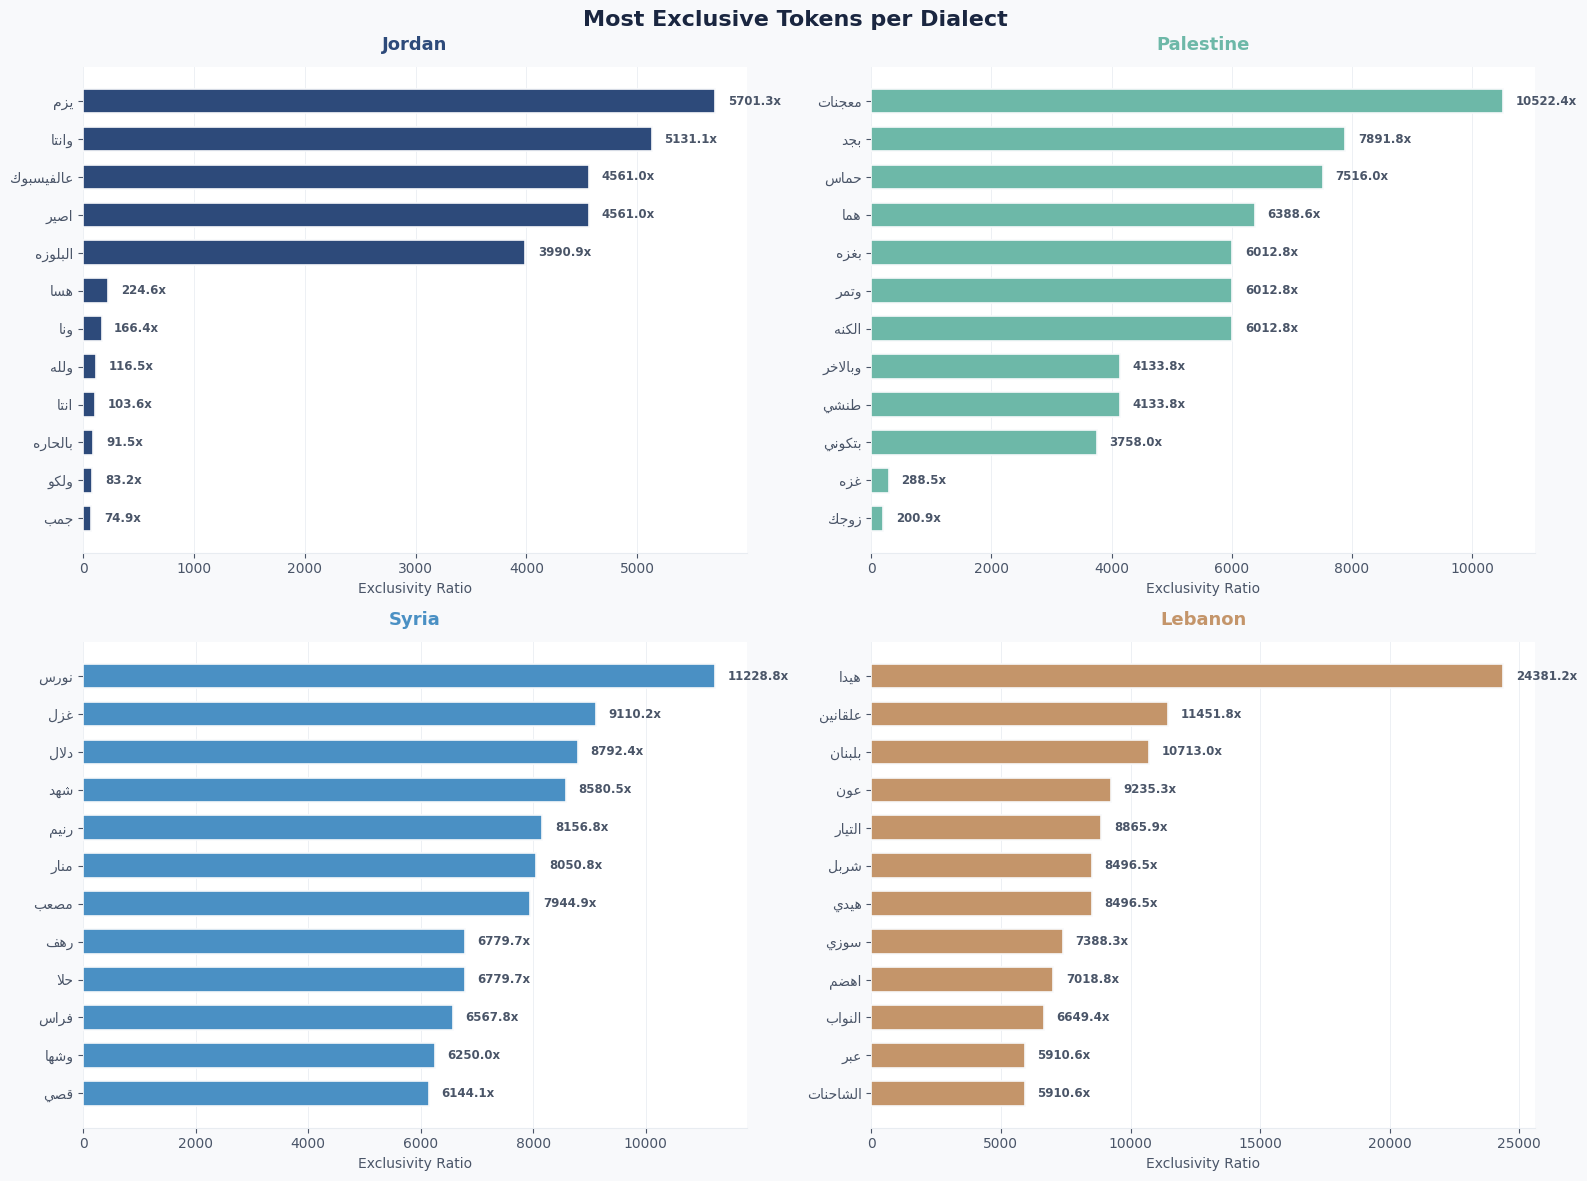

In [31]:
# =========================
# Font setup
# =========================
import matplotlib.pyplot as plt
from matplotlib import font_manager

# Load font
font_ar = font_manager.FontProperties(family='DejaVu Sans')        # Arabic

# =========================
# Arabic reshape
# =========================
import arabic_reshaper
from bidi.algorithm import get_display
import re

def is_arabic(text):
    return bool(re.search(r'[\u0600-\u06FF]', str(text)))

def reshape_ar(text):
    try:
        return get_display(arabic_reshaper.reshape(str(text)))
    except:
        return text

# =========================
# Plot
# =========================
country_colors = {
    "Jordan"   : "#2D4A7A",
    "Palestine": "#6DB8A8",
    "Syria"    : "#4A90C4",
    "Lebanon"  : "#C4956A",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor=BG_COLOR)

fig.suptitle("Most Exclusive Tokens per Dialect",
             fontsize=16, fontweight='bold', color=TEXT_DARK)

for ax, country in zip(axes.flatten(),
                       ["Jordan", "Palestine", "Syria", "Lebanon"]):

    df_c    = df_export[df_export['true_label'] == country]
    results = exclusivity_analysis(df_c, df_export, country,
                                   top_n=15, min_freq=5, ratio_thresh=3.0)

    if not results:
        ax.axis('off')
        continue

    raw_tokens = [r[0] for r in results[:12]]
    tokens = [reshape_ar(t) if is_arabic(t) else t for t in raw_tokens]
    ratios = [r[3] for r in results[:12]]

    color  = country_colors[country]

    bars = ax.barh(tokens[::-1], ratios[::-1],
                   color=color, edgecolor=BG_COLOR,
                   linewidth=1.2, height=0.65)

    # 🔥 SET FONT PER LABEL
    ax.set_yticklabels(tokens[::-1])
    for label, raw in zip(ax.get_yticklabels(), raw_tokens[::-1]):
        if is_arabic(raw):
            label.set_fontproperties(font_ar)
    
    # value text
    for bar, val in zip(bars, ratios[::-1]):
        ax.text(bar.get_width() + max(ratios)*0.02,
                bar.get_y() + bar.get_height()/2,
                f"{val:.1f}x",
                va='center', ha='left',
                fontsize=8.5, color=TEXT_MID,
                fontweight='bold')

    ax.spines[['left','top','right']].set_visible(False)
    ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
    ax.yaxis.grid(False)
    ax.set_axisbelow(True)

    ax.set_facecolor(CARD_COLOR)
    ax.set_title(country, fontsize=13,
                 fontweight='bold', color=color)

    ax.set_xlabel("Exclusivity Ratio",
                  fontsize=10, color=TEXT_MID,
                  )

    ax.tick_params(axis='y', labelsize=10)

fig.tight_layout()
save_and_show("token_exclusivity")


=== TOKEN EKSKLUSIF JORDAN (vs semua) ===
Token           | Freq     | Freq Lain  | Rasio   
--------------------------------------------------
  يزم             | 10       | 0          | MUTLAK
  وانتا           | 9        | 0          | MUTLAK
  عالفيسبوك       | 8        | 0          | MUTLAK
  اصير            | 8        | 0          | MUTLAK
  البلوزه         | 7        | 0          | MUTLAK
  هسا             | 27       | 1          | 224.6x
  ونا             | 20       | 1          | 166.4x
  ولله            | 14       | 1          | 116.5x
  انتا            | 37       | 3          | 103.6x
  بالحاره         | 11       | 1          | 91.5x
  ولكو            | 10       | 1          | 83.2x
  جمب             | 9        | 1          | 74.9x
  بالعقل          | 9        | 1          | 74.9x
  همه             | 17       | 2          | 71.2x
  اعيط            | 8        | 1          | 66.6x


🖼️ Saved: artifacts/lightgbm_balanced_weighted/image/token_exclusivity_jordan.png


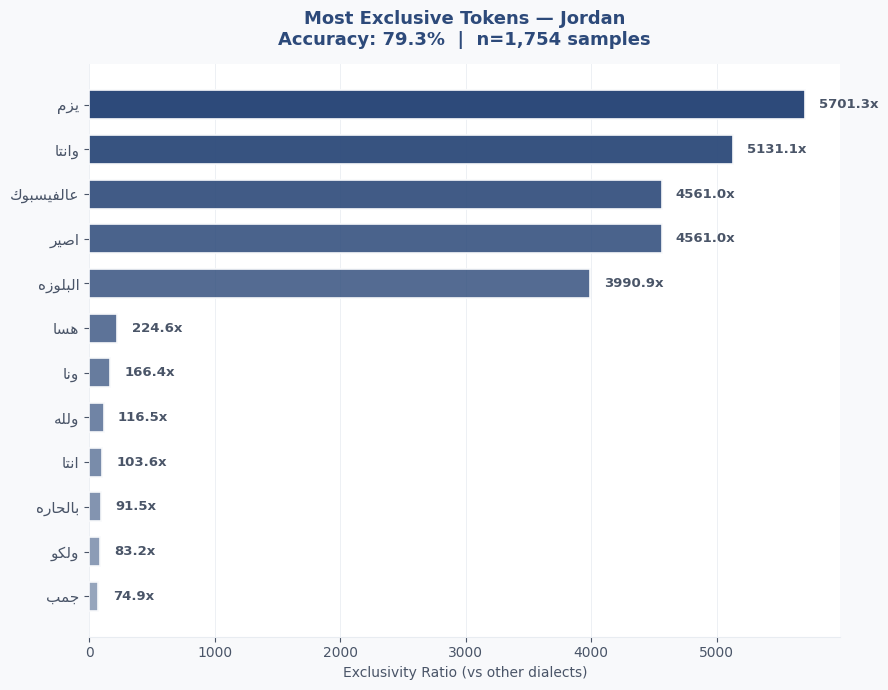


=== TOKEN EKSKLUSIF PALESTINE (vs semua) ===
Token           | Freq     | Freq Lain  | Rasio   
--------------------------------------------------
  معجنات          | 28       | 0          | MUTLAK
  بجد             | 21       | 0          | MUTLAK
  حماس            | 20       | 0          | MUTLAK
  هما             | 17       | 0          | MUTLAK
  بغزه            | 16       | 0          | MUTLAK
  وتمر            | 16       | 0          | MUTLAK
  الكنه           | 16       | 0          | MUTLAK
  وبالاخر         | 11       | 0          | MUTLAK
  طنشي            | 11       | 0          | MUTLAK
  بتكوني          | 10       | 0          | MUTLAK
  غزه             | 56       | 1          | 288.5x
  زوجك            | 39       | 1          | 200.9x
  هادا            | 37       | 1          | 190.6x
  علشان           | 17       | 1          | 87.6x
  زيك             | 16       | 1          | 82.4x


🖼️ Saved: artifacts/lightgbm_balanced_weighted/image/token_exclusivity_palestine.png


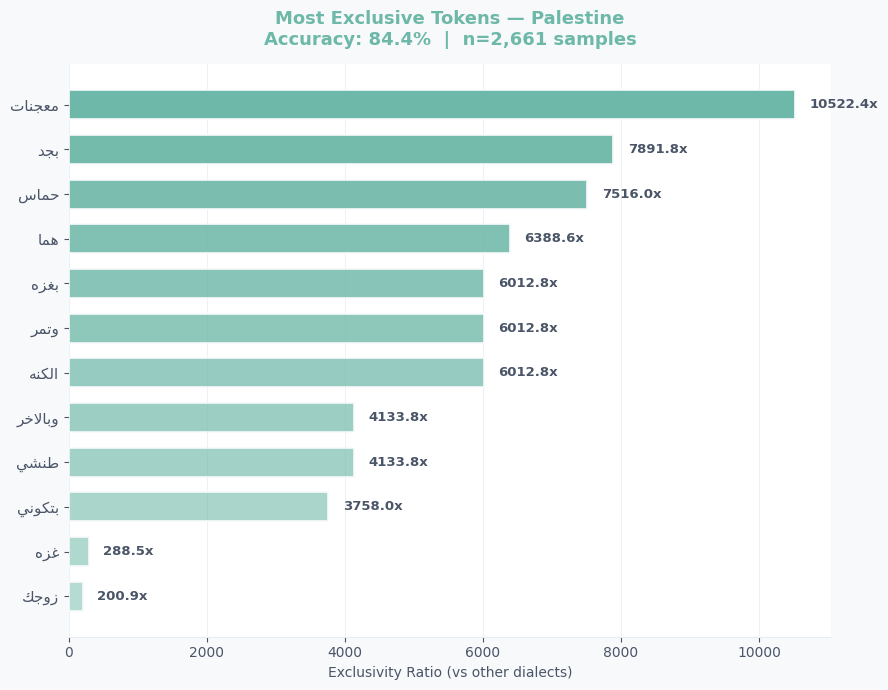


=== TOKEN EKSKLUSIF SYRIA (vs semua) ===
Token           | Freq     | Freq Lain  | Rasio   
--------------------------------------------------
  نورس            | 106      | 0          | MUTLAK
  غزل             | 86       | 0          | MUTLAK
  دلال            | 83       | 0          | MUTLAK
  شهد             | 81       | 0          | MUTLAK
  رنيم            | 77       | 0          | MUTLAK
  منار            | 76       | 0          | MUTLAK
  مصعب            | 75       | 0          | MUTLAK
  رهف             | 64       | 0          | MUTLAK
  حلا             | 64       | 0          | MUTLAK
  فراس            | 62       | 0          | MUTLAK
  وشها            | 59       | 0          | MUTLAK
  قصي             | 58       | 0          | MUTLAK
  منال            | 54       | 0          | MUTLAK
  رفيف            | 53       | 0          | MUTLAK
  حاتم            | 53       | 0          | MUTLAK


🖼️ Saved: artifacts/lightgbm_balanced_weighted/image/token_exclusivity_syria.png


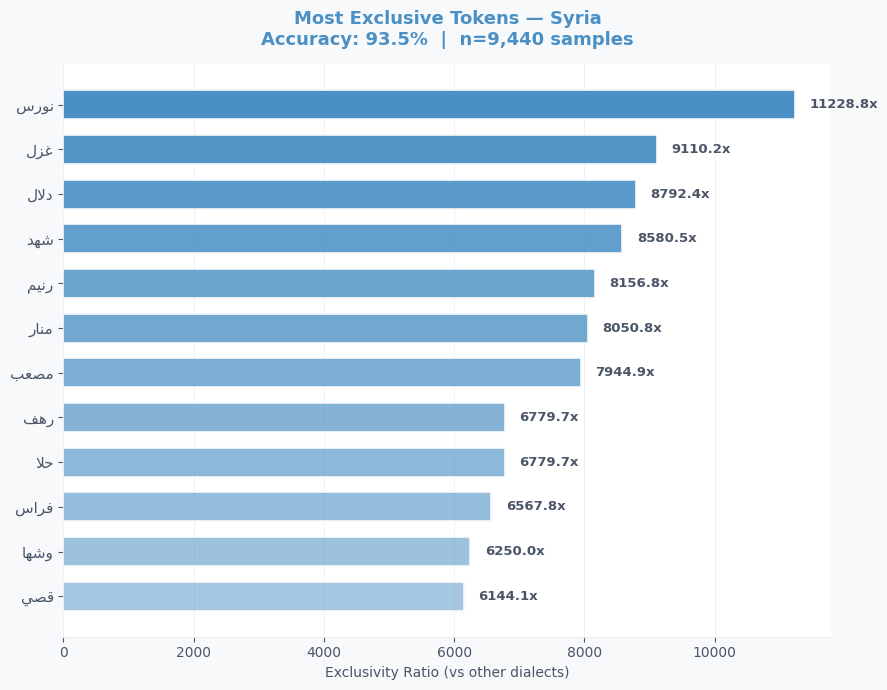


=== TOKEN EKSKLUSIF LEBANON (vs semua) ===
Token           | Freq     | Freq Lain  | Rasio   
--------------------------------------------------
  هيدا            | 66       | 0          | MUTLAK
  علقانين         | 31       | 0          | MUTLAK
  بلبنان          | 29       | 0          | MUTLAK
  عون             | 25       | 0          | MUTLAK
  التيار          | 24       | 0          | MUTLAK
  شربل            | 23       | 0          | MUTLAK
  هيدي            | 23       | 0          | MUTLAK
  سوزي            | 20       | 0          | MUTLAK
  اهضم            | 19       | 0          | MUTLAK
  النواب          | 18       | 0          | MUTLAK
  عبر             | 16       | 0          | MUTLAK
  الشاحنات        | 16       | 0          | MUTLAK
  ياخور           | 15       | 0          | MUTLAK
  هلق             | 15       | 0          | MUTLAK
  السياسيين       | 14       | 0          | MUTLAK


🖼️ Saved: artifacts/lightgbm_balanced_weighted/image/token_exclusivity_lebanon.png


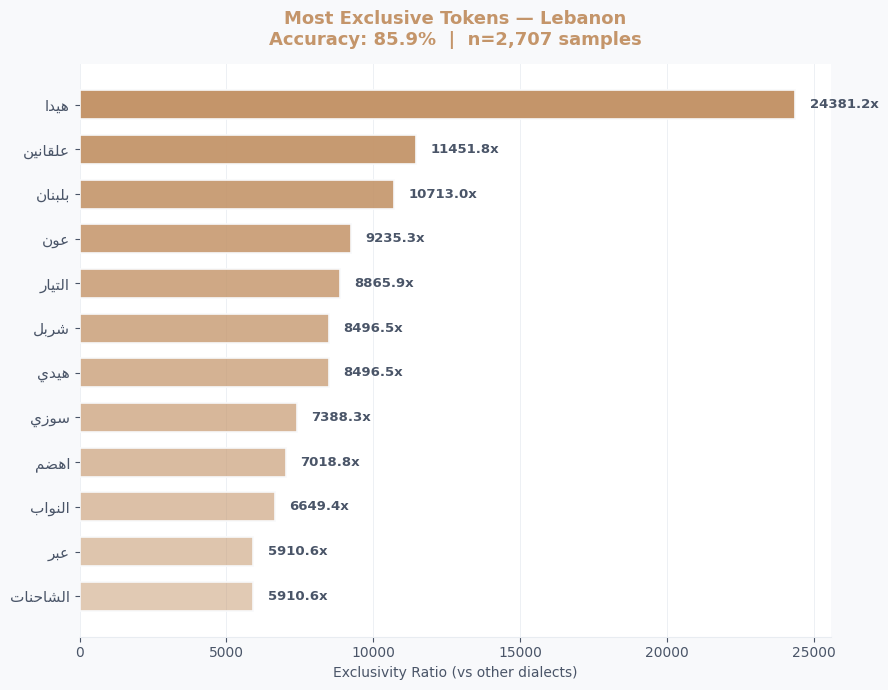

In [32]:
import re
from matplotlib import font_manager

# =========================
# Plot per country
# =========================
for country in ["Jordan", "Palestine", "Syria", "Lebanon"]:

    df_c    = df_export[df_export['true_label'] == country]
    results = exclusivity_analysis(df_c, df_export, country,
                                   top_n=15, min_freq=5, ratio_thresh=3.0)

    if not results:
        print(f"⚠️ No results for {country}, skipping.")
        continue

    raw_tokens = [r[0] for r in results[:12]]
    tokens = [reshape_ar(t) if is_arabic(t) else t for t in raw_tokens]
    ratios = [r[3] for r in results[:12]]
    color  = country_colors[country]

    n_bars = len(tokens)
    bar_colors = [
        color + f"{int(255 * (0.5 + 0.5 * (i / max(n_bars-1,1)))):02x}"
        for i in range(n_bars)
    ]

    fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG_COLOR)
    ax.set_facecolor(CARD_COLOR)

    bars = ax.barh(tokens[::-1], ratios[::-1],
                   color=bar_colors,
                   edgecolor=BG_COLOR,
                   linewidth=1.2,
                   height=0.65)

    # 🔥 SET FONT PER LABEL (INI KUNCI)
    ax.set_yticklabels(tokens[::-1])
    for label, raw in zip(ax.get_yticklabels(), raw_tokens[::-1]):
        if is_arabic(raw):
            label.set_fontproperties(font_ar)
        else:
            label.set_fontproperties(font_en)

    # value text (pakai font latin)
    for bar, val in zip(bars, ratios[::-1]):
        ax.text(
            bar.get_width() + max(ratios) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}x",
            va='center',
            ha='left',
            fontsize=9.5,
            color=TEXT_MID,
            fontweight='bold',
            
        )

    # subtitle info
    n_correct = (df_export[df_export['true_label'] == country]['correct']).sum()
    n_total   = len(df_export[df_export['true_label'] == country])
    acc       = n_correct / n_total * 100

    ax.set_title(
        f"Most Exclusive Tokens — {country}\n"
        f"Accuracy: {acc:.1f}%  |  n={n_total:,} samples",
        fontsize=13,
        fontweight='bold',
        color=color,
        pad=14,
        
    )

    ax.set_xlabel(
        "Exclusivity Ratio (vs other dialects)",
        fontsize=10,
        color=TEXT_MID,
        
    )

    ax.spines[['left','top','right']].set_visible(False)
    ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
    ax.yaxis.grid(False)
    ax.set_axisbelow(True)

    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=10)

    fig.tight_layout()
    save_and_show(f"token_exclusivity_{country.lower()}")

## Demo

In [33]:
def predict_custom(text, model, feat, le, top_n=4):
    # Build input DataFrame sesuai format yang diharapkan feat.transform()
    clean_w = clean_noise(text)
    clean_c = clean_char(text)
    
    df_input = pd.DataFrame({
        "text"       : [text],
        "clean_word" : [clean_w],
        "clean_char" : [clean_c],
    })
    
    # Transform & predict
    X_input  = feat.transform(df_input)
    
    if drop_list:
        X_input, _ = drop_blocks(X_input, block_slices, drop_list)
    
    proba    = model.predict_proba(X_input, num_iteration=model.best_iteration_)[0]
    pred_idx = np.argmax(proba)
    
    # Display hasil
    print("=" * 45)
    print(f"Input   : {text}")
    print(f"Clean   : {clean_w}")
    print("-" * 45)
    print(f"Prediksi: {le.classes_[pred_idx]}  ({proba[pred_idx]*100:.1f}%)")
    print("-" * 45)
    print("Probabilitas semua kelas:")
    for idx in np.argsort(proba)[::-1]:
        bar = "█" * int(proba[idx] * 30)
        print(f"  {le.classes_[idx]:12s}: {proba[idx]*100:5.1f}%  {bar}")
    print("=" * 45)
    
    return le.classes_[pred_idx], proba


# ── Ganti teks di sini ──────────────────────────────────
sample_texts = [
    "شو بدك تاكل اليوم",
    "ايش تبي تاكل اليوم",
    "شو عملت امبارح",
]

for text in sample_texts:
    predict_custom(text, model, feat, le)
    print()

Input   : شو بدك تاكل اليوم
Clean   : شو بدك تاكل اليوم
---------------------------------------------
Prediksi: Lebanon  (69.0%)
---------------------------------------------
Probabilitas semua kelas:
  Lebanon     :  69.0%  ████████████████████
  Syria       :  26.7%  ████████
  Palestine   :   2.5%  
  Jordan      :   1.8%  

Input   : ايش تبي تاكل اليوم
Clean   : ايش تبي تاكل اليوم
---------------------------------------------
Prediksi: Palestine  (53.6%)
---------------------------------------------
Probabilitas semua kelas:
  Palestine   :  53.6%  ████████████████
  Lebanon     :  43.0%  ████████████
  Jordan      :   2.4%  
  Syria       :   0.9%  

Input   : شو عملت امبارح
Clean   : شو عملت امبارح
---------------------------------------------
Prediksi: Jordan  (94.0%)
---------------------------------------------
Probabilitas semua kelas:
  Jordan      :  94.0%  ████████████████████████████
  Syria       :   3.8%  █
  Lebanon     :   1.2%  
  Palestine   :   0.9%  



In [34]:
predict_custom("شو بدك", model, feat, le)

Input   : شو بدك
Clean   : شو بدك
---------------------------------------------
Prediksi: Jordan  (80.0%)
---------------------------------------------
Probabilitas semua kelas:
  Jordan      :  80.0%  ███████████████████████
  Lebanon     :  14.9%  ████
  Syria       :   4.8%  █
  Palestine   :   0.3%  


('Jordan', array([0.79996571, 0.148667  , 0.00306518, 0.04830211]))